In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [2]:
np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Packages loaded.")

Packages loaded successfully. Starting analytics pipeline...


In [3]:
funds = [f"Fund_{i:02d}" for i in range(1, 41)]
risk_options = ['Low', 'Moderate', 'High']
risk_grades = np.random.choice(risk_options, size=40, p=[0.3, 0.4, 0.3])
fund_risk_map = dict(zip(funds, risk_grades))

In [4]:
dates = pd.date_range(start="2023-01-01", end="2025-12-31", freq='B')
returns_df = pd.DataFrame(np.random.normal(0.0004, 0.01, size=(len(dates), 40)), index=dates, columns=funds)

In [5]:
for fund in funds:
    if fund_risk_map[fund] == 'High':
        returns_df[fund] *= 1.8  # Aggressive swings
    elif fund_risk_map[fund] == 'Low':
        returns_df[fund] *= 0.5

In [6]:
num_investors = 500
investor_ids = [f"INV_{i:04d}" for i in range(1, num_investors + 1)]
cohort_years = np.random.choice([2023, 2024, 2025], size=num_investors, p=[0.4, 0.4, 0.2])
investor_cohort_map = dict(zip(investor_ids, cohort_years))

tx_records = []
for inv_id in investor_ids:
    start_year = investor_cohort_map[inv_id]
    sip_amount = int(np.random.choice([2000, 5000, 10000, 25000], p=[0.4, 0.3, 0.2, 0.1]))
    preferred_fund = np.random.choice(funds)
    
    start_date = datetime(start_year, np.random.randint(1, 6), np.random.randint(1, 28))
    total_months = np.random.randint(5, 24)  # Simulate active lifecycle lengths
    
    current_date = start_date
    for _ in range(total_months):
        if current_date > datetime(2025, 12, 31):
            break
        tx_records.append({
            'investor_id': inv_id,
            'cohort_year': start_year,
            'date': current_date,
            'amount': sip_amount,
            'fund': preferred_fund
        })
        gap_days = int(np.random.choice([28, 30, 31, 42], p=[0.2, 0.6, 0.1, 0.1]))
        current_date += timedelta(days=gap_days)

tx_df = pd.DataFrame(tx_records)
print(f"Environment built: Simulated {len(tx_df)} baseline asset movements.")

Environment built: Simulated 6416 baseline asset movements.


In [7]:
var_95 = returns_df.quantile(0.05)
cvar_95 = pd.Series(index=funds, dtype=float)

for fund in funds:
    tail_losses = returns_df[fund][returns_df[fund] <= var_95[fund]]
    cvar_95[fund] = tail_losses.mean()

In [9]:
hhi_series = pd.Series(index=funds, dtype=float)
for fund in funds:
    allocations = np.random.dirichlet(np.ones(5))
    hhi_series[fund] = np.sum(allocations ** 2)

In [10]:
var_cvar_report = pd.DataFrame({
    'Risk_Grade': [fund_risk_map[f] for f in funds],
    'VaR_95': var_95,
    'CVaR_95': cvar_95,
    'HHI_Sector': hhi_series
})

var_cvar_report.to_csv('var_cvar_report.csv', index_label='Fund_ID')
print("Task Complete: 'var_cvar_report.csv' written to root folder.")
var_cvar_report.head()

Task Complete: 'var_cvar_report.csv' written to root folder.


,Risk_Grade,VaR_95,CVaR_95,HHI_Sector
Fund_01,Moderate,-0.014964,-0.019236,0.429009
Fund_02,High,-0.028153,-0.037353,0.548662
Fund_03,High,-0.030572,-0.038138,0.427909
Fund_04,Moderate,-0.016148,-0.019803,0.702022
Fund_05,Low,-0.008341,-0.010138,0.332775


In [11]:
rolling_mean = returns_df.rolling(90).mean()
rolling_std = returns_df.rolling(90).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

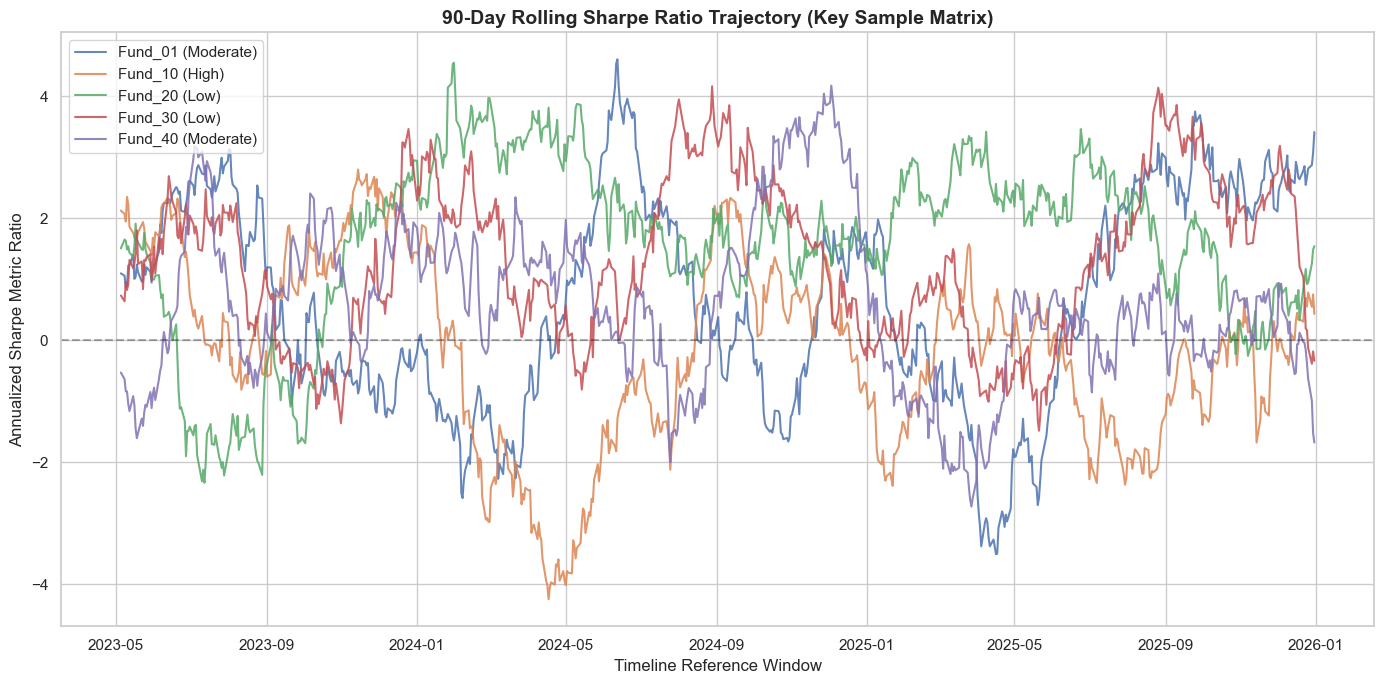

In [14]:
key_funds = ['Fund_01', 'Fund_10', 'Fund_20', 'Fund_30', 'Fund_40']

plt.figure(figsize=(14, 7))
for fund in key_funds:
    plt.plot(rolling_sharpe.index, rolling_sharpe[fund], label=f"{fund} ({fund_risk_map[fund]})", alpha=0.85)

plt.title('90-Day Rolling Sharpe Ratio Trajectory (Key Sample Matrix)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline Reference Window', fontsize=12)
plt.ylabel('Annualized Sharpe Metric Ratio', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig('rolling_sharpe_chart.png', dpi=300)
plt.show()

In [13]:
cohort_summary = tx_df.groupby('cohort_year').agg(
    Avg_SIP_Amount=('amount', 'mean'),
    Total_Capital_Invested=('amount', 'sum'),
    Unique_Active_Wallets=('investor_id', 'nunique')
).reset_index()

In [16]:
preference_matrix = tx_df.groupby(['cohort_year', 'fund']).size().reset_index(name='allocations')
top_preferences = preference_matrix.sort_values(['cohort_year', 'allocations'], ascending=[True, False]).drop_duplicates('cohort_year')

cohort_summary = cohort_summary.merge(top_preferences[['cohort_year', 'fund']], on='cohort_year')
cohort_summary.rename(columns={'fund': 'Top_Fund_Preference'}, inplace=True)

print("\n INVESTOR COHORT PROFILES ")
print(cohort_summary.to_string(index=False))


 INVESTOR COHORT PROFILES 
 cohort_year  Avg_SIP_Amount  Total_Capital_Invested  Unique_Active_Wallets Top_Fund_Preference Top_Fund_Preference
        2023     6574.615947                17975000                    199             Fund_09             Fund_09
        2024     7023.916293                18796000                    191             Fund_15             Fund_15
        2025     6800.198807                 6841000                    110             Fund_23             Fund_23


In [19]:
continuity_records = []

for investor, operational_history in tx_df.groupby('investor_id'):
    if len(operational_history) >= 6:
        sorted_timeline = operational_history['date'].sort_values()
        calendar_gaps = sorted_timeline.diff().dt.days.dropna()
        
        avg_gap = calendar_gaps.mean()
        max_gap = calendar_gaps.max()
        risk_status = "at-risk" if max_gap > 35 else "active"
        
        continuity_records.append({
            'investor_id': investor,
            'avg_days_between_sip': round(avg_gap, 2),
            'max_observed_gap': max_gap,
            'status': risk_status
        })

sip_continuity_df = pd.DataFrame(continuity_records)
print("\n--- SIP CONTINUITY PERFORMANCE PROFILE ---")
print(sip_continuity_df['status'].value_counts(normalize=False))
print(f"\nTotal At-Risk Systematic Profiles Identified: {len(sip_continuity_df[sip_continuity_df['status']=='at-risk'])}")


--- SIP CONTINUITY PERFORMANCE PROFILE ---
status
at-risk    320
active     151
Name: count, dtype: int64

Total At-Risk Systematic Profiles Identified: 320


In [20]:
def query_fund_recommendations(risk_appetite):
    # Derive absolute static current Sharpe ratio vector
    annual_sharpe = (returns_df.mean() / returns_df.std()) * np.sqrt(252)
    
    lookup_frame = var_cvar_report.copy()
    lookup_frame['Sharpe_Ratio'] = annual_sharpe
    
    matched_profile = lookup_frame[lookup_frame['Risk_Grade'].str.upper() == risk_appetite.upper()]
    recommendations = matched_profile.sort_values(by='Sharpe_Ratio', ascending=False).head(3)
    
    print(f"\nTop 3 Recommended Funds for a [{risk_appetite.upper()}] Risk Appetite Profile:")
    return recommendations[['Risk_Grade', 'Sharpe_Ratio', 'VaR_95', 'HHI_Sector']]

In [21]:
query_fund_recommendations(risk_appetite='Moderate')


Top 3 Recommended Funds for a [MODERATE] Risk Appetite Profile:


,Risk_Grade,Sharpe_Ratio,VaR_95,HHI_Sector
Fund_19,Moderate,1.068314,-0.015357,0.289318
Fund_29,Moderate,0.993433,-0.015174,0.368647
Fund_21,Moderate,0.885502,-0.014849,0.333420


In [25]:
dir()

['In',
 'Out',
 '_',
 '_10',
 '_11',
 '_12',
 '_13',
 '_14',
 '_15',
 '_16',
 '_21',
 '_4',
 '_5',
 '_6',
 '_7',
 '_8',
 '_9',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__pandas',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'allocations',
 'avg_gap',
 'calendar_gaps',
 'cohort_summary',
 'cohort_years',
 'continuity_records',
 'current_date',
 'cvar_95',
 'dataframe_columns',
 'dataframe_hash',
 'dates',
 'datetime',
 'df',
 'dtypes_str',
 'exit',
 'fund',
 'fund_risk_map',
 'funds',
 'gap_days',
 'get_dataframes',
 'get_ipython',
 'getpass',
 'hashlib',
 'hhi_series',
 'import_pandas_safely',
 'inv_id',
 'investor',
 'investor_cohort_map',
 'investor_ids',
 'is_data_frame',
 '